In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmocean as cmo

ds = xr.open_dataset("FlocMod.nc", decode_times=False)
print(ds)

nt = len(ds.time) - 1



<xarray.Dataset> Size: 2MB
Dimensions:  (time: 600, Ds: 40, N: 10)
Coordinates:
  * time     (time) float32 2kB 0.0 29.0 59.0 ... 1.791e+04 1.794e+04 1.797e+04
  * Ds       (Ds) float32 160B 1e-05 1.137e-05 1.293e-05 ... 0.001319 0.0015
  * N        (N) float32 40B 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 10.0
Data variables:
    ssc      (time, Ds, N) float64 2MB ...
    np       (Ds) float64 320B ...
    mass     (Ds) float64 320B ...
    G        (time, N) float64 48kB ...
Attributes:
    title:    floc mod test
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


In [ ]:
# Mass conservation check 
mass = ds.mass
print(ds.mass)
# print(ds.ssc.isel(time=0, z=7).values)# * mass)))
# print("mass=", np.sum( ds.ssc.isel(time=0, z=7).values))# * mass))
print("mass=", np.sum( ds.ssc.isel(time=10, z=7).values * mass))
print(ds.ssc.isel(time=3, z=7).values)
print(mass.values)

<xarray.DataArray 'mass' (Ds: 40)> Size: 320B
[40 values with dtype=float64]
Coordinates:
  * Ds       (Ds) float32 160B 1e-05 1.137e-05 1.293e-05 ... 0.001319 0.0015
Attributes:
    units:      kg/particle
    long_name:  mass of each floc (fractal!)


ValueError: Dimensions {'z'} do not exist. Expected one or more of ('time', 'Ds', 'N')

<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_843869/366158708.py:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[j].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=Ds).values*1e6))


Text(0.5, 0, 'Time [hr]')

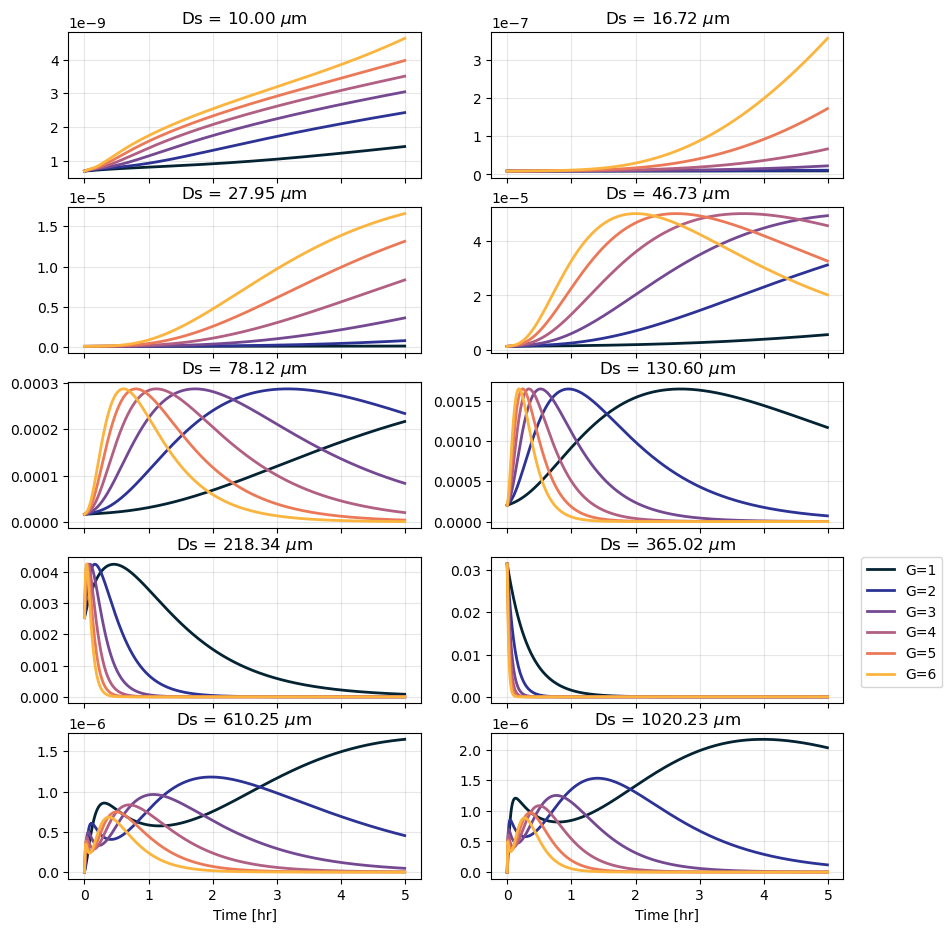

In [19]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 11), sharex=True, sharey=False)
axs = axs.flatten()


for j, Ds in enumerate(range(0, 40, 4)):
    axs[j].grid(alpha=0.3)
    axs[j].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=Ds).values*1e6))
    time = ds.time.values / 3600
    for i in range(0, 6):
        G = ds.G.isel(time=1, N=i)
        #ssc       (time, Ds, N)
        mass = ds.mass.isel(Ds=Ds)
        s0 = ds.ssc.isel(N=i).isel(Ds=Ds)
        axs[j].plot(time, s0*mass, color=cmo.cm.thermal(i/6), linewidth=2, label="G=%d" % G)

axs[-3].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
axs[-1].set_xlabel("Time [hr]")
axs[-2].set_xlabel("Time [hr]")

<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_843869/3776637192.py:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[i].set_ylabel("D [$\mu$m]")
/tmp/ipykernel_843869/3776637192.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


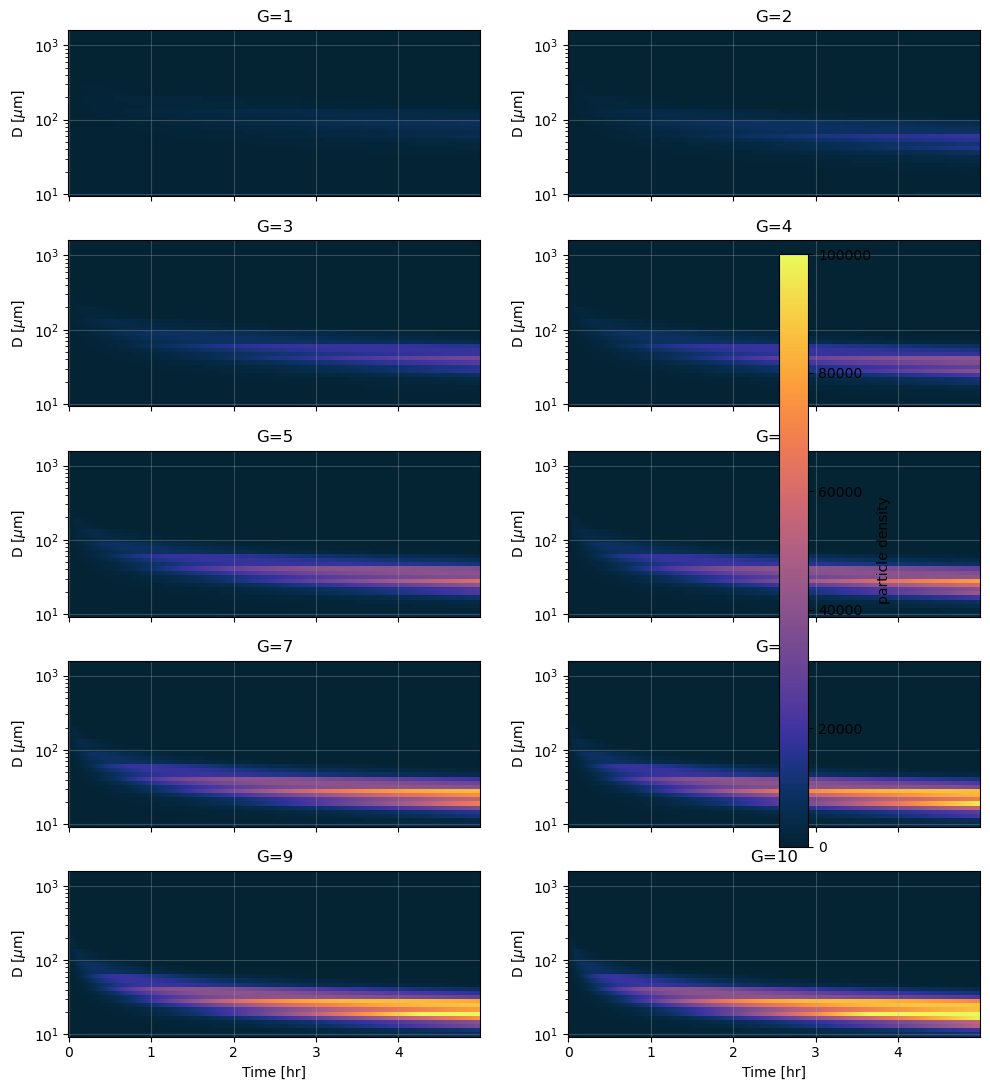

In [32]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 11), sharex=True, sharey=False)
axs = axs.flatten()

for i in range(0, 10):
    G = ds.G.isel(time=1, N=i)
    axs[i].grid(alpha=0.3)
    axs[i].set_title("G=%d" % G)
    time = ds.time.values / 3600
    ssc = ds.ssc.isel(N=i)
    h = axs[i].pcolormesh(time, ds.Ds.values*1e6, ssc.T, cmap=cmo.cm.thermal, shading='auto', vmin=0, vmax=1e5)
    axs[i].set_yscale("log")
    axs[i].set_ylabel("D [$\mu$m]")

plt.colorbar(h, ax=axs, orientation='vertical', label="particle density", shrink=0.7)
axs[-1].set_xlabel("Time [hr]")
axs[-2].set_xlabel("Time [hr]")
plt.tight_layout()

In [ ]:
# for t in range(nt//10, stop, stop//6):
#     for i, d in enumerate(range(ST,36,6)):
#         # i = i*4
#         color = cmo.cm.thermal(t/stop) 
#         # var = ds.Kz.isel(time=t)
#         var = ds.Kq.isel(time=t)
#         ax3.plot(var, -ds.z, color=color, label="T=%d min" % (t*10/60))


#         var = ds.ssc.isel(time=t).isel(Ds=d)
#         mass = ds.mass.isel(Ds=d)


#         h= axs[i].plot(var[0:-1]*mass*1e3, -ds.z[0:-1], color=color, label="T=%d min" % (t*10/60), linewidth=2)
#         axs[i].grid(alpha=0.3)
#         axs[i].set_xlabel("SSC (g/L)")
#         # axs2[i].grid(alpha=0.3)

#         axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))
#         axs[i].set_ylim(-10, 0)
#         # axs2[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))


# axs[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
# # axs2[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
# axs[0].set_ylabel("Depth (m)")

# ax3.set_xlabel("$K_z$ (m$^2$/s)")
# ax3.grid(alpha=0.3)
# ax3.set_ylabel("Depth (m)")
# ax3.set_ylim(-10, 0)

<>:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1336168/3740303478.py:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))


(-10.0, 0.0)

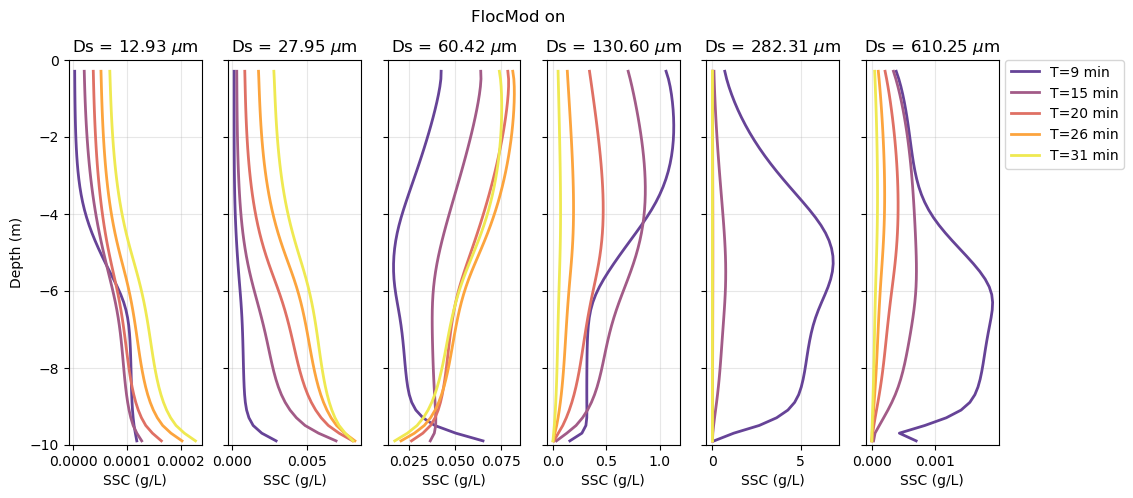

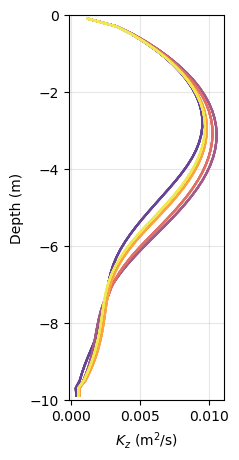

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(12, 5), sharex=False, sharey=True)
axs = axs.flatten()
plt.suptitle("FlocMod on <-> advection/diff off")



fig3 = plt.figure(figsize=(2, 5))
ax3 = plt.gca() 

ST = 2 
stop = nt//3
for t in range(nt//10, stop, stop//6):
    for i, d in enumerate(range(ST,36,6)):
        # i = i*4
        color = cmo.cm.thermal(t/stop) 
        # var = ds.Kz.isel(time=t)
        var = ds.Kq.isel(time=t)
        ax3.plot(var, -ds.z, color=color, label="T=%d min" % (t*10/60))


        var = ds.ssc.isel(time=t).isel(Ds=d)
        mass = ds.mass.isel(Ds=d)


        h= axs[i].plot(var[0:-1]*mass*1e3, -ds.z[0:-1], color=color, label="T=%d min" % (t*10/60), linewidth=2)
        axs[i].grid(alpha=0.3)
        axs[i].set_xlabel("SSC (g/L)")
        # axs2[i].grid(alpha=0.3)

        axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))
        axs[i].set_ylim(-10, 0)
        # axs2[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))


axs[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
# axs2[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
axs[0].set_ylabel("Depth (m)")

ax3.set_xlabel("$K_z$ (m$^2$/s)")
ax3.grid(alpha=0.3)
ax3.set_ylabel("Depth (m)")
ax3.set_ylim(-10, 0)

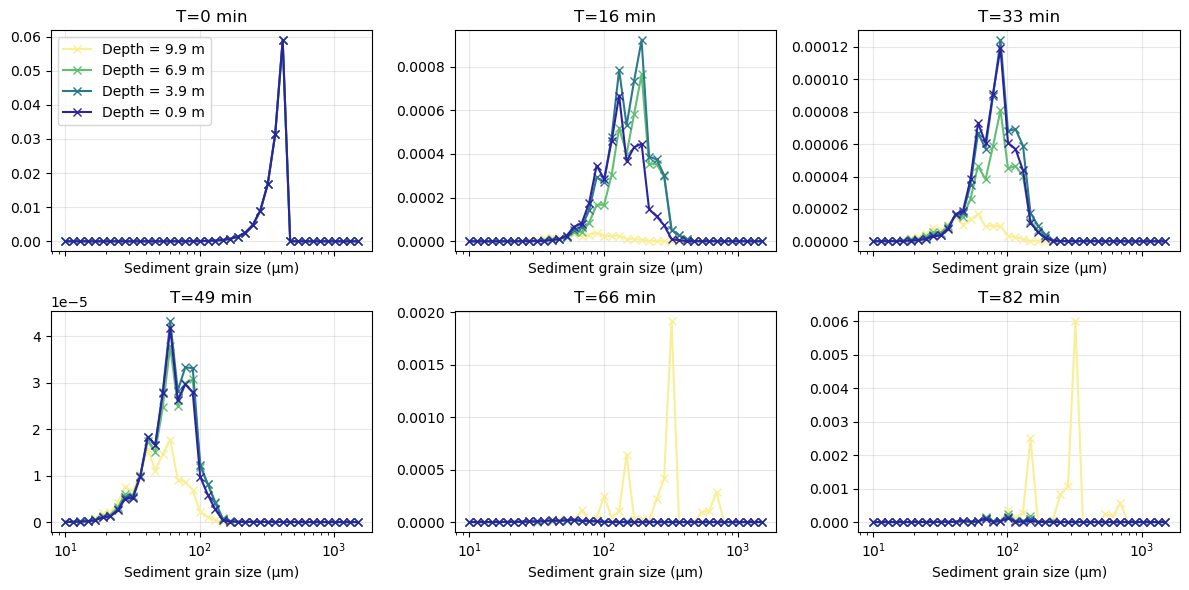

In [133]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=True, sharey=False)
axs = axs.flatten()

z = ds.z.values
mass = ds.mass.values
for i,t in enumerate(range(0, nt, nt//6)):
    # var = ds.Kz.isel(time=12)
    if i>5:
        continue
    for dep in range(0, 50, 15):
        var = ds.ssc.isel(z=dep).isel(time=t) * mass
        axs[i].plot(ds.Ds.values*1e6, var, '-x', color=cmo.cm.haline(z[dep]/10), label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
       

    axs[i].set_xscale('log')
    axs[i].grid(alpha=0.3)
    axs[i].set_title("T=%d min" % (t*10/60))
    # axs[i].set_yscale('log')

    axs[i].set_xlabel("Sediment grain size (µm)")
    # axs[i].set_ylabel("10$^6$ particles/m$^3$")
axs[0].legend()
plt.tight_layout()

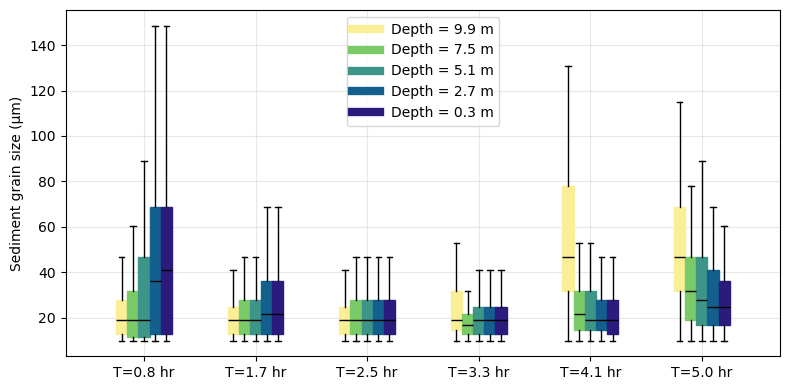

In [134]:
fig = plt.figure(figsize=(8, 4))
ax = plt.gca()

z = ds.z.values
mass = ds.mass.values
nt = len(ds.time) - 1
D = ds.Ds.values*1e6
for i, dep in enumerate(range(0, len(z), len(z)//4)):
    ax.plot([],[], color=cmo.cm.haline(z[dep]/10), label="Depth = %2.1f m" % z[dep], linewidth=6) #,color=cmo.cm.thermal(t/nt))
    for j,t in enumerate(range(100, nt, nt//6)):
        # print(j, t)
        # var = ds.Kz.isel(time=12)
        var = ds.ssc.isel(z=dep).isel(time=t) 

        expanded_D = np.repeat(D, var)
        ax.boxplot(expanded_D, positions=[j+i*0.1], widths=0.1, patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor=cmo.cm.haline(z[dep]/10), color=cmo.cm.haline(z[dep]/10)), medianprops=dict(color='black')) #,color=cmo.cm.thermal(t/nt))
        # (ds.Ds.values*1e6, var, 'x', color=cmo.cm.haline(z[dep]/10), label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
ax.legend()    

ax.grid(alpha=0.3)
ax.set_xticks([i+0.2 for i,j in enumerate(range(100, nt, nt//6))])
labels = ["T=%2.1f hr" % (ds.time[t]/3600) for t in range(100, nt, nt//6)]
ax.set_xticklabels(labels)
    # axs[i].set_xscale('log')
    # axs[i].grid(alpha=0.3)
    # axs[i].set_title("T=%d min" % (t*10/60))
    # # axs[i].set_yscale('log')

ax.set_ylabel("Sediment grain size (µm)")
    # axs[i].set_ylabel("10$^6$ particles/m$^3$")
axs[0].legend()
plt.tight_layout()

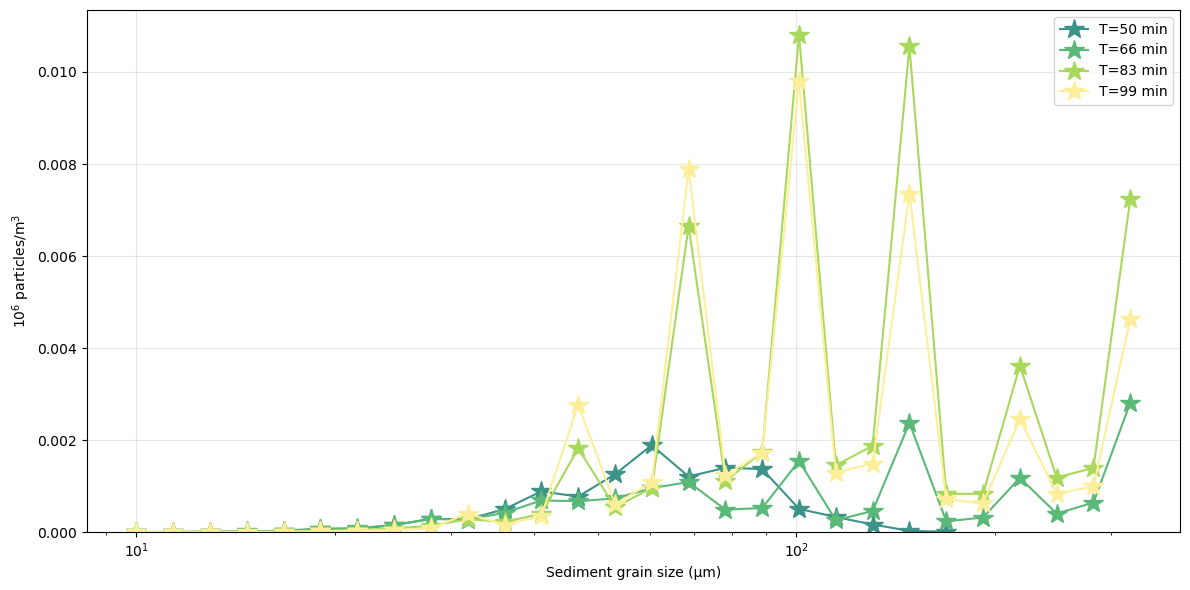

In [135]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 6), sharex=True, sharey=True)

z = ds.z.values
for i,t in enumerate(range(300, nt, nt//6)):
    # var = ds.Kz.isel(time=12)

    label="T=%d min" % (t*10/60)
    # print(i, t, time)
    
    var = ds.ssc.isel(time=t).sum(dim='z')
    var[var<2] = np.nan
    axs.plot(ds.Ds.values*1e6, var*mass, '-*', color=cmo.cm.haline(t/nt), markersize=15, label=label) #,color=cmo.cm.thermal(t/nt))
# axs[i].plot(ds.ssc.isel(time=400).isel(Ds=i), ds.z)
    # print(var)
# print(var.values) 
    axs.set_xscale('log')
    axs.grid(alpha=0.3)
    # axs.set_yscale('log')

    axs.set_xlabel("Sediment grain size (µm)")
    axs.set_ylabel("10$^6$ particles/m$^3$")
axs.legend()
axs.set_ylim(0,)
plt.tight_layout()

(0.16388888657093048, 49.747222900390625)

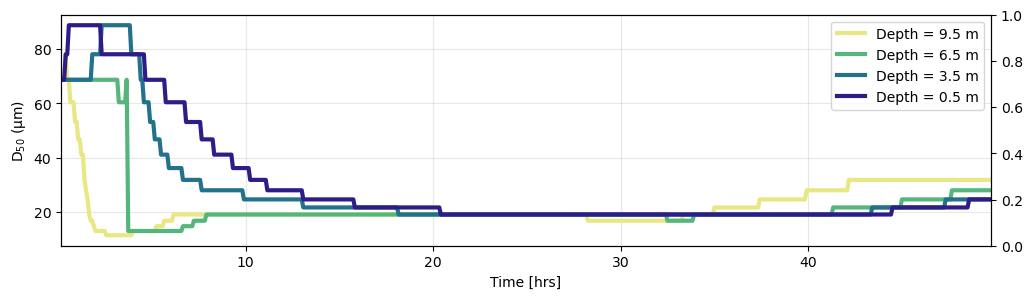

In [136]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 3), sharex=True, sharey=True)
ax2 = ax.twinx()

z = ds.z.values

for dep in range(2, 50, 15):
    hours = ds.time.values / 360
    var = ds.ssc.isel(z=dep) # .isel(time=t)
    # print(ds.Ds.values.shape, var.values.shape)
    # broadcast Ds to match var shape
    Ds = np.broadcast_to(ds.Ds.values, var.values.shape)
    weights = var.values + 1e-3
    mean_d = np.percentile(Ds, axis=1, q=50, weights=weights, method="inverted_cdf")
    ax.plot(hours, mean_d*1e6, color=cmo.cm.haline(z[dep]/10), linewidth=3, label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
    # kz = ds.Kq.mean(dim="z")
    # ax2.plot(hours, kz, linewidth=3, alpha = 0.5)

# ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend()
# ax.set_xlim(0, 5)
ax.set_xlabel("Time [hrs]")
ax.set_ylabel("D$_{50}$ (µm)")
ax.set_xlim(hours[2], hours[-3])
# axs[i].set_ylabel("10$^6$ particles/m$^3$")
# axs[0].legend()
# plt.tight_layout()

<xarray.Dataset> Size: 12MB
Dimensions:  (time: 600, Ds: 40, z: 50)
Coordinates:
  * time     (time) float32 2kB 0.0 29.0 59.0 ... 1.791e+04 1.794e+04 1.797e+04
  * Ds       (Ds) float32 160B 1e-05 1.137e-05 1.293e-05 ... 0.001319 0.0015
  * z        (z) float32 200B 9.9 9.7 9.5 9.3 9.1 8.9 ... 0.9 0.7 0.5 0.3 0.1
Data variables:
    ssc      (time, Ds, z) float64 10MB ...
    np       (Ds) float64 320B ...
    mass     (Ds) float64 320B 1.388e-12 2.604e-12 4.887e-12 ... 0.03402 0.06384
    U        (time, z) float64 240kB ...
    Kq       (time, z) float64 240kB ...
    Nu       (time, z) float64 240kB ...
    C        (time, z) float64 240kB ...
    Kz       (time, z) float64 240kB ...
    L        (time, z) float64 240kB ...
    Q2       (time, z) float64 240kB ...
    Q2L      (time, z) float64 240kB ...
    N_BV2    (time, z) float64 240kB ...
Attributes:
    title:    testing
[0.         0.00805556 0.01638889 0.02472222 0.03305556]
81.23141991315741


Text(0.5, 1.0, 'U')

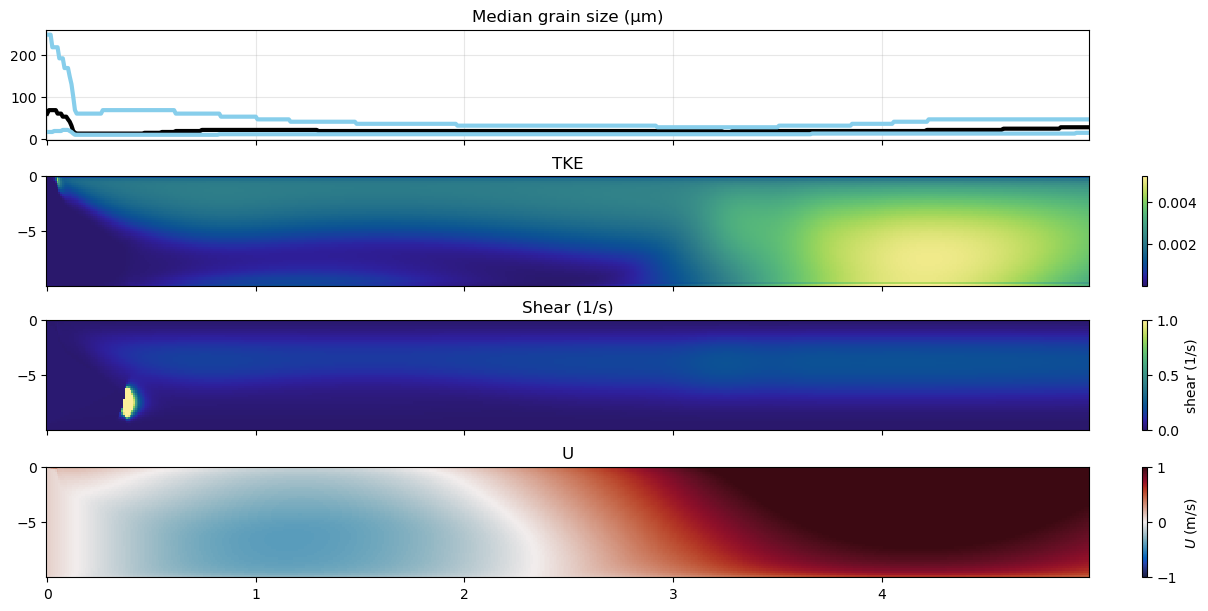

In [137]:
print(ds)

fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 6), sharex=True, sharey=False, constrained_layout=True)

z = -ds.z.values
time = ds.time.values /3600 # * 60/3600
mass = ds.mass.values
Ds = ds.Ds.values*1e6
print(time[0:5])

ind= 15
ssc = ds.ssc #.isel(Ds=ind)  #* mass[ind]
# print(max(ssc.values.flatten()))
# h = axs[0].pcolormesh(time, z, ssc.T, cmap=cmo.cm.rain) #, color=cmo.cm.haline)
# h = plt.colorbar(h, label="Sediment (mg/L)")

weights = ssc.mean(dim='z') # * mass 

Ds_broadcasted = np.broadcast_to(Ds[:, np.newaxis], weights.T.shape)
mean_d = np.percentile(Ds_broadcasted, axis=0, q=50, weights=weights.T, method="inverted_cdf")
axs[0].plot(time, mean_d, color='black', linewidth=3) #,color=cmo.cm.thermal(t/nt))
# axs[0].set_yscale('log')
mean_d = np.percentile(Ds_broadcasted, axis=0, q=16, weights=weights.T, method="inverted_cdf")
axs[0].plot(time, mean_d, color='skyblue', linewidth=3) #,color=cmo.cm.thermal(t/nt))
mean_d = np.percentile(Ds_broadcasted, axis=0, q=84, weights=weights.T, method="inverted_cdf")
axs[0].plot(time, mean_d, color='skyblue', linewidth=3) #,color=cmo.cm.thermal(t/nt))
axs[0].grid(alpha=0.3)
axs[0].set_title("Median grain size (µm)")
# assert(False)
# kappa = ds.Nu #isel(Ds=ind)  * mass[ind]
# print(max(kappa.values.flatten()))
# h = axs[1].pcolormesh(time, z, np.log(kappa.T), cmap=cmo.cm.haline) #, color=cmo.cm.haline)
# h = plt.colorbar(h, label=r"$\kappa$ (m$^2$/s)")

kappa = ds.Q2 #isel(Ds=ind)  * mass[ind]
h = axs[1].pcolormesh(time, z, kappa.T, cmap=cmo.cm.haline) #, color=cmo.cm.haline)
h = plt.colorbar(h) #, label=r"$\kappa$ (m$^2$/s)")
axs[1].set_title("TKE")


# kappa = ds.Nu #isel(Ds=ind)  * mass[ind]
shear =np.sqrt(ds.Kq)/ (ds.Q2 / ds.Q2L)**2  # np.sqrt(ds.Q2) # *100
print(max(shear.values.flatten()))
h = axs[2].pcolormesh(time, z, shear.T, cmap=cmo.cm.haline,vmin=0, vmax=1) #, color=cmo.cm.haline)
axs[2].set_title("Shear (1/s)")
h = plt.colorbar(h, label=r"shear (1/s)")


U = ds.U #isel(Ds=ind)  * mass[ind]
h = axs[3].pcolormesh(time, z, U.T, cmap=cmo.cm.balance, vmin=-1, vmax=1) #, color=cmo.cm.haline)
h = plt.colorbar(h, label=r"$U$ (m/s)")
axs[3].set_title("U")
# kappa = ds.Kz #isel(Ds=ind)  * mass[ind]
# print(max(kappa.values.flatten()))
# h = axs[1].pcolormesh(time, z, np.log(kappa.T), cmap=cmo.cm.haline) #, color=cmo.cm.haline)
# h = plt.colorbar(h, label=r"$\kappa$ (m$^2$/s)")